## Naive Bayes Model

### Modeling objective
The modeling objective is to build and test a Naive Bayes model that uses banking data to predict whether a customer will churn. If a customer churns, it means they left the bank and took their business elsewhere. If we can predict customers who are likely to churn, we can take measures to retain them before they do. These measures could be promotions, discounts, or other incentives to boost customer satisfaction and, therefore, retention.

### Target variable
Remember, our target variable is called Exited. This is a Boolean value that indicates whether or not a customer left the bank (0 = did not leave, 1 = did leave). For each customer, our model will predict whether they should have a 0 or a 1 in the Exited column.

In [1]:
import pandas as pd
import numpy as np
import math 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [2]:
churn_raw = pd.read_csv('./raw_data/churn_df.csv')
churn_raw.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0.047619,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.025641,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,0,1


In [3]:
churn_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Loyalty            10000 non-null  float64
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 937.6 KB


In [4]:
# Check nulls and blanks
churn_raw.isna().sum()

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Loyalty              0
Geography_Germany    0
Geography_Spain      0
dtype: int64

In [5]:
# Check balance of classes
churn_raw['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
churn_raw['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [8]:
# feature selection

churn_data = churn_raw[['Exited','CreditScore','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','Loyalty','Geography_Germany','Geography_Spain']]

In [10]:
churn_data.head()

,Exited,CreditScore,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Loyalty,Geography_Germany,Geography_Spain
0,1,619,0.00,1,1,1,101348.88,0.047619,0,0
1,0,608,83807.86,1,0,1,112542.58,0.024390,0,1
2,1,502,159660.80,3,1,0,113931.57,0.190476,0,0
3,0,699,0.00,2,0,0,93826.63,0.025641,0,0
4,0,850,125510.82,1,1,1,79084.10,0.046512,0,1


In [46]:
y = churn_data[['Exited']] # Dependent variable
x = churn_data.drop('Exited',axis=1) # Independet variables

x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.75,random_state=42,stratify=y)

In [20]:
x_train.describe()

,CreditScore,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Loyalty,Geography_Germany,Geography_Spain
count,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000
mean,649.725600,76440.279792,1.550400,0.71440,0.521600,101318.354276,0.138082,0.25080,0.245200
std,97.220997,62101.834040,0.590931,0.45179,0.499633,57686.860103,0.087999,0.43356,0.430292
min,350.000000,0.000000,1.000000,0.00000,0.000000,90.070000,0.000000,0.00000,0.000000
25%,584.000000,0.000000,1.000000,0.00000,0.000000,53338.562500,0.066667,0.00000,0.000000
50%,651.000000,96658.935000,2.000000,1.00000,1.000000,100972.795000,0.129032,0.00000,0.000000
75%,718.000000,127160.670000,2.000000,1.00000,1.000000,151759.570000,0.200000,1.00000,0.000000
max,850.000000,212692.970000,4.000000,1.00000,1.000000,199909.320000,0.476190,1.00000,1.000000


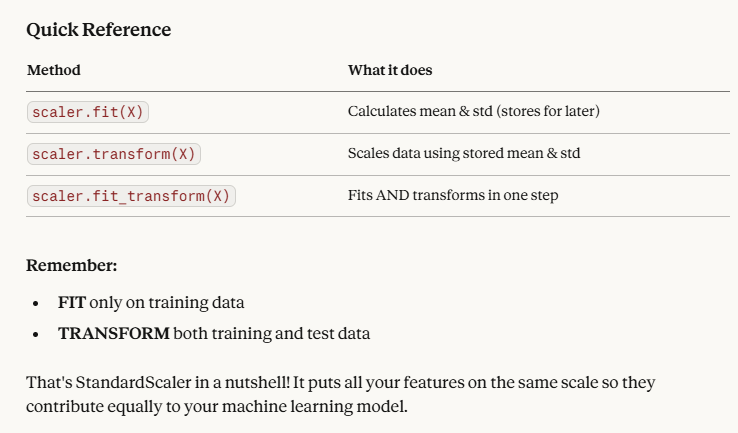

In [50]:
# Some of the independet variables are not in the same scale
# feature transformation

from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_minMax = MinMaxScaler()
scaler_stdScl = StandardScaler()

#Scale Independent Variables
x_train_mm = scaler_minMax.fit_transform(x_train)
x_train_stdScl = scaler_stdScl.fit_transform(x_train)

x_test_mm = scaler_minMax.transform(x_test)
x_test_stdScl = scaler_stdScl.transform(x_test)

# Check the differences in the value when normalizing data
# by two different methods

print(x_train_mm[0])
print('=='*30)
print(x_train_stdScl[0])

[0.654      0.5640217  0.         0.         0.         0.79189467
 0.         0.         0.        ]
[ 0.28059635  0.70097571 -0.93159786 -1.58158166 -1.0441748   0.98842129
 -1.56945226 -0.57858195 -0.56995988]


In [58]:
# See how the minMax Scaler works

gaussian_NB_Model_mms = GaussianNB().fit(x_train_mm,y_train)
mm_prediction = gaussian_NB_Model_mms.predict(x_test_mm)

#Model Metric Scoring 
print(f'accuracy_score: {accuracy_score(y_test,mm_prediction):.4f}')
print(f'precision_score: {precision_score(y_test,mm_prediction):.4f}')
print(f'recall_score: {recall_score(y_test,mm_prediction):.4f}')
print(f'F1_score: {f1_score(y_test,mm_prediction):.4f}')

accuracy_score: 0.8080
precision_score: 0.5595
recall_score: 0.2709
F1_score: 0.3651


c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


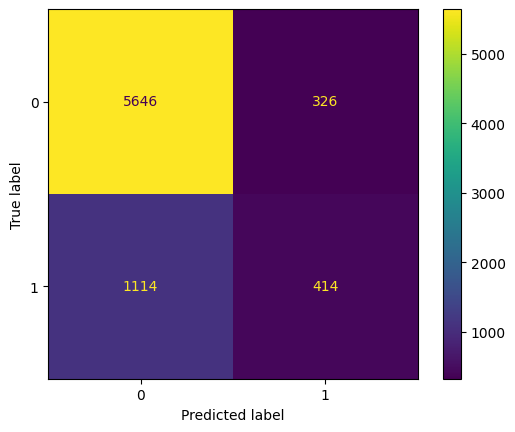

In [61]:
confMatrx = confusion_matrix(y_test,mm_prediction,labels=gaussian_NB_Model_mms.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrx,display_labels=gaussian_NB_Model_mms.classes_)
disp.plot()


In [62]:
# See how the standardScaling perform

ss_gaussian_nb_model = GaussianNB().fit(x_train_stdScl,y_train)
ss_prediction = ss_gaussian_nb_model.predict(x_test_stdScl)

# See how the model performs on each metric

print(f'accuracy_score: {accuracy_score(y_test,ss_prediction):.4f}')
print(f'precision_score: {precision_score(y_test,ss_prediction):.4f}')
print(f'recall_score: {recall_score(y_test,ss_prediction):.4f}')
print(f'F1_score: {f1_score(y_test,ss_prediction):.4f}')

accuracy_score: 0.8080
precision_score: 0.5595
recall_score: 0.2709
F1_score: 0.3651


c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


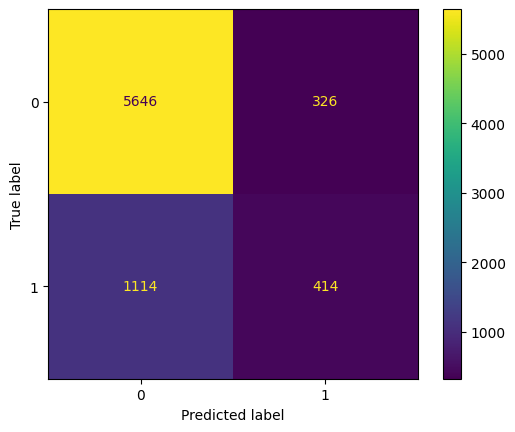

In [63]:
confMatrix = confusion_matrix(y_test,ss_prediction,labels=ss_gaussian_nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrix,display_labels=ss_gaussian_nb_model.classes_)
disp.plot()